In [2]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import os 
import tensorflow as tf 
import keras 

from keras.layers import Dense,Flatten ,SimpleRNN
from keras.models import Sequential




ModuleNotFoundError: No module named 'numpy'

In [ ]:
ls logs/

fit/         fit_test/    fit_tfkeras/


In [ ]:
!pip install kagglehub

  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
Using cached kagglehub-1.0.0-py3-none-any.whl (70 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [kagglehub]


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("szrlee/stock-time-series-20050101-to-20171231")

print("Path to dataset files:", path)

Path to dataset files: /Users/anuragpanchal/.cache/kagglehub/datasets/szrlee/stock-time-series-20050101-to-20171231/versions/3


In [ ]:
for file in sorted(os.listdir(path)):
    print(file)

AABA_2006-01-01_to_2018-01-01.csv
AAPL_2006-01-01_to_2018-01-01.csv
AMZN_2006-01-01_to_2018-01-01.csv
AXP_2006-01-01_to_2018-01-01.csv
BA_2006-01-01_to_2018-01-01.csv
CAT_2006-01-01_to_2018-01-01.csv
CSCO_2006-01-01_to_2018-01-01.csv
CVX_2006-01-01_to_2018-01-01.csv
DIS_2006-01-01_to_2018-01-01.csv
GE_2006-01-01_to_2018-01-01.csv
GOOGL_2006-01-01_to_2018-01-01.csv
GS_2006-01-01_to_2018-01-01.csv
HD_2006-01-01_to_2018-01-01.csv
IBM_2006-01-01_to_2018-01-01.csv
INTC_2006-01-01_to_2018-01-01.csv
JNJ_2006-01-01_to_2018-01-01.csv
JPM_2006-01-01_to_2018-01-01.csv
KO_2006-01-01_to_2018-01-01.csv
MCD_2006-01-01_to_2018-01-01.csv
MMM_2006-01-01_to_2018-01-01.csv
MRK_2006-01-01_to_2018-01-01.csv
MSFT_2006-01-01_to_2018-01-01.csv
NKE_2006-01-01_to_2018-01-01.csv
PFE_2006-01-01_to_2018-01-01.csv
PG_2006-01-01_to_2018-01-01.csv
TRV_2006-01-01_to_2018-01-01.csv
UNH_2006-01-01_to_2018-01-01.csv
UTX_2006-01-01_to_2018-01-01.csv
VZ_2006-01-01_to_2018-01-01.csv
WMT_2006-01-01_to_2018-01-01.csv
XOM_2006-

In [ ]:
df = pd.read_csv(path+'/'+'AAPL_2006-01-01_to_2018-01-01.csv',index_col='Date',parse_dates=['Date'])

In [ ]:
df

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,10.34,10.68,10.32,10.68,201853036,AAPL
2006-01-04,10.73,10.85,10.64,10.71,155225609,AAPL
2006-01-05,10.69,10.70,10.54,10.63,112396081,AAPL
2006-01-06,10.75,10.96,10.65,10.90,176139334,AAPL
2006-01-09,10.96,11.03,10.82,10.86,168861224,AAPL
...,...,...,...,...,...,...
2017-12-22,174.68,175.42,174.50,175.01,16349444,AAPL
2017-12-26,170.80,171.47,169.68,170.57,33185536,AAPL
2017-12-27,170.10,170.78,169.71,170.60,21498213,AAPL


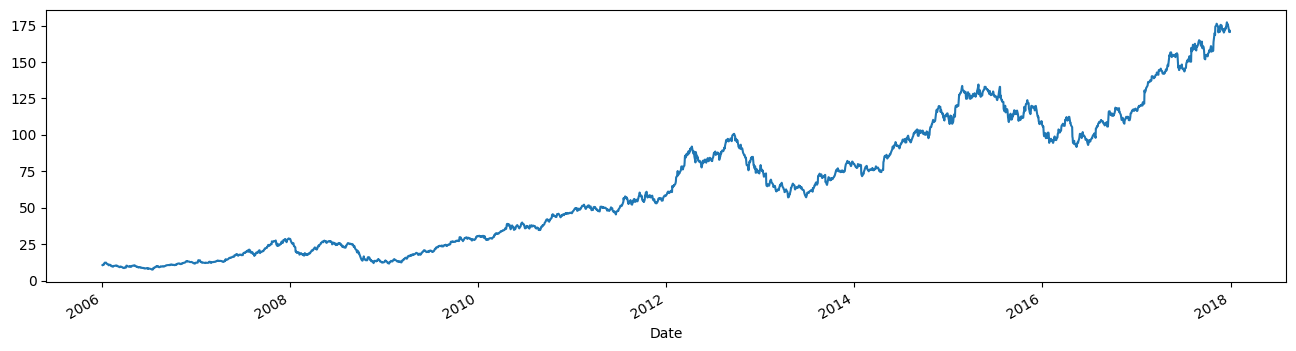

In [ ]:
df['High'].plot(figsize=(16,4))
plt.show()

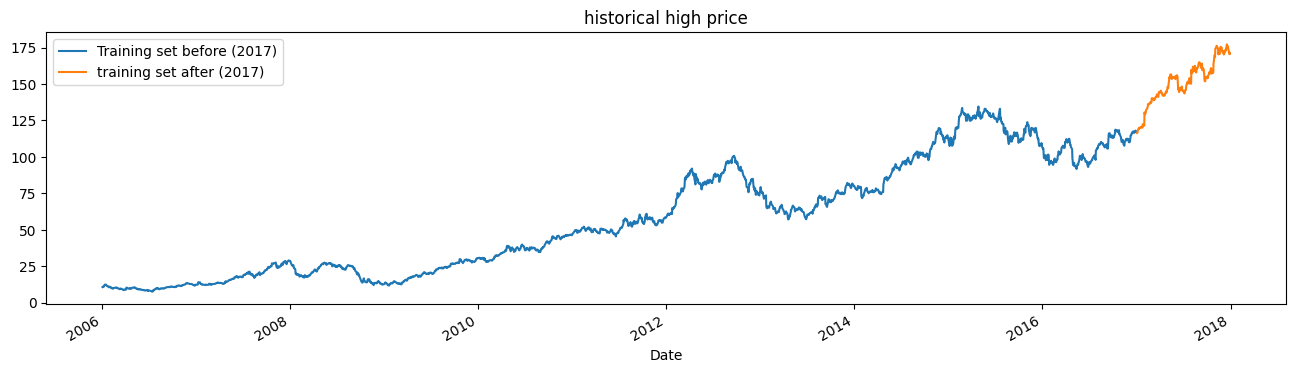

In [ ]:
df['High'][:'2016'].plot(figsize=(16,4),legend=True)
df['High']['2017':].plot(figsize=(16,4),legend=True)
plt.legend(['Training set before (2017)','training set after (2017)'])
plt.title('historical high price')
plt.show()

In [ ]:
df[:'2016'].iloc[:,1:2].values

array([[ 10.68],
       [ 10.85],
       [ 10.7 ],
       ...,
       [118.02],
       [117.11],
       [117.2 ]], shape=(2768, 1))

In [ ]:
# split the data train and test 
train = df[:'2016'].iloc[:,1:2].values
test = df['2017':].iloc[:,1:2].values

In [ ]:
train.shape

(2768, 1)

In [ ]:
test.shape

(251, 1)

In [ ]:
x_train = []
y_train = []
x_test = []
y_test = []
timestamp = 30
for i in range(timestamp,len(train)):
    x_train.append(train[i-timestamp:i,0])
    y_train.append(train[i,0])

In [ ]:
x_train[0]


array([10.68, 10.85, 10.7 , 10.96, 11.03, 11.7 , 12.11, 12.34, 12.29,
       12.34, 12.01, 11.67, 11.43, 11.37, 11.35, 11.07, 10.78, 10.51,
       10.94, 10.91, 10.92, 10.77, 10.4 , 10.36,  9.93,  9.87,  9.89,
        9.67,  9.54,  9.73])

In [ ]:
y_train[0]

np.float64(9.95)

In [ ]:
for i in range(timestamp,len(test)):
    x_test.append(test[i-timestamp:i,0])
    y_test.append(test[i,0])

In [ ]:
x_test[0]


array([116.33, 116.51, 116.86, 118.16, 119.43, 119.38, 119.93, 119.3 ,
       119.62, 120.24, 120.5 , 120.09, 120.45, 120.81, 120.1 , 122.1 ,
       122.44, 122.35, 121.63, 121.39, 130.49, 129.39, 129.19, 130.5 ,
       132.09, 132.22, 132.44, 132.94, 133.82, 135.09])

In [ ]:
y_test[0]

np.float64(136.27)

In [ ]:
x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
x_train

array([[ 10.68,  10.85,  10.7 , ...,   9.67,   9.54,   9.73],
       [ 10.85,  10.7 ,  10.96, ...,   9.54,   9.73,   9.95],
       [ 10.7 ,  10.96,  11.03, ...,   9.73,   9.95,  10.14],
       ...,
       [107.81, 107.68, 110.23, ..., 116.51, 116.52, 117.8 ],
       [107.68, 110.23, 110.35, ..., 116.52, 117.8 , 118.02],
       [110.23, 110.35, 110.54, ..., 117.8 , 118.02, 117.11]],
      shape=(2738, 30))

In [ ]:
model = Sequential(
    [
        Dense(128,activation='relu',input_shape=(x_train.shape[1],)),
        Dense(64,activation='relu'),
        Dense(32,activation='relu'),
        Dense(1)
    ]
)
model.summary()

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,337 (56.00 KB)

 Trainable params: 14,337 (56.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
history = model.fit(x_train,y_train,epochs=50,batch_size=30,validation_data=(x_test,y_test))

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 131.8668 - mae: 5.1112 - val_loss: 19.7986 - val_mae: 3.4550
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 632us/step - loss: 7.4849 - mae: 1.9169 - val_loss: 16.6474 - val_mae: 3.1577
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 651us/step - loss: 5.8699 - mae: 1.7062 - val_loss: 25.3409 - val_mae: 4.1019
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 635us/step - loss: 5.0939 - mae: 1.6005 - val_loss: 90.3792 - val_mae: 8.9525
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 6.6115 - mae: 1.7520 - val_loss: 14.3873 - val_mae: 2.8959
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - loss: 3.8787 - mae: 1.3873 - val_loss: 13.1746 - val_mae: 2.7708
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 649us/step - loss: 3.5665 - mae: 1.3271 - val_loss: 10.8978 - val_mae: 2.4788
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step - loss: 3.6412 - mae: 1.3445 - val_loss: 17.0788 - val_mae: 3.4689
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/s

In [ ]:
y_pred_ann = model.predict(x_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [ ]:
x_train.shape

(2738, 30)

In [ ]:
model_rnn = Sequential(
    [
        SimpleRNN(128,activation='relu',input_shape=(30,1)),
        Dense(64,activation='relu'),
        Dense(32,activation='relu'),
        Dense(1)
    ]
)
model_rnn.summary()

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,009 (105.50 KB)

 Trainable params: 27,009 (105.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
x_train_rnn = x_train.reshape(x_train.shape[0], x_train.shape[1], 1)
x_test_rnn = x_test.reshape(x_test.shape[0], x_test.shape[1], 1)

model_rnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
history_rnn = model_rnn.fit(
    x_train_rnn, y_train,
    epochs=50, batch_size=30,
    validation_data=(x_test_rnn, y_test)
)

y_pred = model_rnn.predict(x_test_rnn).ravel()


Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 190.2908 - mae: 5.3446 - val_loss: 5.0005 - val_mae: 1.5939
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9402 - mae: 0.9609 - val_loss: 7.3797 - val_mae: 2.1106
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8884 - mae: 0.9448 - val_loss: 4.7532 - val_mae: 1.5467
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8744 - mae: 0.9360 - val_loss: 6.4599 - val_mae: 1.9474
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8708 - mae: 0.9412 - val_loss: 4.4364 - val_mae: 1.4828
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.7518 - mae: 0.9043 - val_loss: 4.4098 - val_mae: 1.4850
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6683 - mae: 0.8847 - val_loss: 4.6752 - val_mae: 1.5702
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6391 - mae: 0.8744 - val_loss: 3.9615 - val_mae: 1.3800
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5431 - mae

In [ ]:
y_pred.shape

(221,)

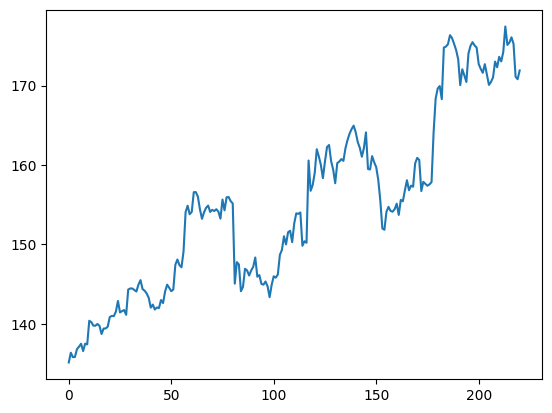

In [ ]:
plt.plot(y_pred,label='Predicted stock Price after 2017')

In [ ]:
y_test.shape

(221,)

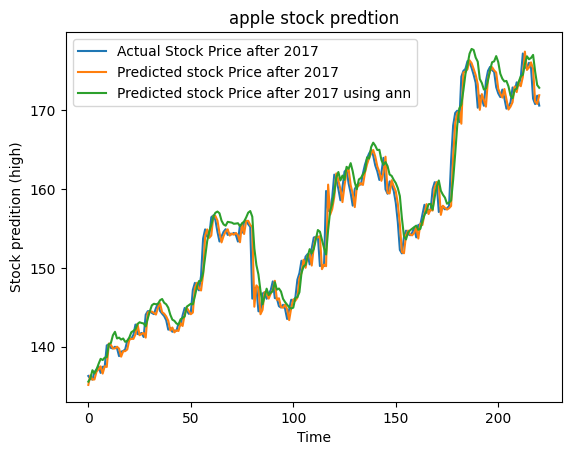

In [ ]:
plt.plot(y_test,label = 'Actual Stock Price after 2017')
plt.plot(y_pred,label='Predicted stock Price after 2017')
plt.plot(y_pred_ann,label='Predicted stock Price after 2017 using ann')
plt.title("apple stock predtion")
plt.xlabel("Time")
plt.ylabel("Stock predition (high)")
plt.legend()
plt.show()

In [ ]:
from keras.callbacks import TensorBoard,ModelCheckpoint
import datetime

In [ ]:
model = Sequential()
model.add(SimpleRNN(16,activation='relu',input_shape=(timestamp,1)))
model.add(Dense(1))
model.summary()

/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

checkpint_file_path= './best_model.h5'
model_checkpoint=ModelCheckpoint(filepath=checkpint_file_path, monitor='val_root_mean_squared_error', save_best_only=True, mode='min')
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['root_mean_squared_error'])

In [ ]:
import os, datetime
from keras.callbacks import TensorBoard

log_dir = os.path.join("logs", "fit", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=30,
    validation_data=(x_test, y_test),
    callbacks=[tensorboard_callback,model_checkpoint]
)


# %load_ext tensorboard
# %tensorboard --logdir logs/fit


Epoch 1/50
80/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1185 - root_mean_squared_error: 1.0548   

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9961 - root_mean_squared_error: 0.9980 - val_loss: 5.0488 - val_root_mean_squared_error: 2.2469
Epoch 2/50
84/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.1024 - root_mean_squared_error: 1.0491

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9580 - root_mean_squared_error: 0.9788 - val_loss: 3.6796 - val_root_mean_squared_error: 1.9182
Epoch 3/50
82/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9244 - root_mean_squared_error: 0.9607

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9441 - root_mean_squared_error: 0.9716 - val_loss: 3.3392 - val_root_mean_squared_error: 1.8273
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9257 - root_mean_squared_error: 0.9622 - val_loss: 4.4594 - val_root_mean_squared_error: 2.1117
Epoch 5/50
81/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9203 - root_mean_squared_error: 0.9586

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9295 - root_mean_squared_error: 0.9641 - val_loss: 3.3050 - val_root_mean_squared_error: 1.8180
Epoch 6/50
83/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9245 - root_mean_squared_error: 0.9608

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9113 - root_mean_squared_error: 0.9546 - val_loss: 2.8133 - val_root_mean_squared_error: 1.6773
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9316 - root_mean_squared_error: 0.9652 - val_loss: 2.9148 - val_root_mean_squared_error: 1.7073
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9141 - root_mean_squared_error: 0.9561 - val_loss: 4.0514 - val_root_mean_squared_error: 2.0128
Epoch 9/50
83/92 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9976 - root_mean_squared_error: 0.9983

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9557 - root_mean_squared_error: 0.9776 - val_loss: 2.7929 - val_root_mean_squared_error: 1.6712
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9394 - root_mean_squared_error: 0.9692 - val_loss: 2.8939 - val_root_mean_squared_error: 1.7011
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9327 - root_mean_squared_error: 0.9657 - val_loss: 3.8954 - val_root_mean_squared_error: 1.9737
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9515 - root_mean_squared_error: 0.9754 - val_loss: 2.8335 - val_root_mean_squared_error: 1.6833
Epoch 13/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9355 - root_mean_squared_error: 0.9672 - val_loss: 3.4891 - val_root_mean_squared_error: 1.8679
Epoch 14/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9591 - root_mean_squared_error: 0.9793 - val_loss: 2.9448 - val_root_mean_squared_error: 1.7160
Epoch 15/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9316 - ro

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9217 - root_mean_squared_error: 0.9601 - val_loss: 2.7858 - val_root_mean_squared_error: 1.6691
Epoch 47/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0096 - root_mean_squared_error: 1.0048 - val_loss: 3.2553 - val_root_mean_squared_error: 1.8042
Epoch 48/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9266 - root_mean_squared_error: 0.9626 - val_loss: 2.8381 - val_root_mean_squared_error: 1.6847
Epoch 49/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9825 - root_mean_squared_error: 0.9912 - val_loss: 2.9464 - val_root_mean_squared_error: 1.7165
Epoch 50/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9819 - root_mean_squared_error: 0.9909 - val_loss: 3.2757 - val_root_mean_squared_error: 1.8099


In [ ]:
ls logs/

fit/         fit_test/    fit_tfkeras/


In [ ]:
ls logs/fit

20260301-151723/ 20260301-153121/


In [ ]:
checkpint_file_path

'.'

In [ ]:
os.listdir()

['CNN_CIFAR2.ipynb',
 'ChurnPredictionMlDl.ipynb',
 '.DS_Store',
 'IntroductionToKeras.ipynb',
 'diabetes.ipynb',
 'mnist.ipynb',
 'ChurnPrediction2.ipynb',
 'DJIA30.ipynb',
 'Dog_cat.ipynb',
 'README.md',
 'temp.ipynb',
 'logs',
 'BreadCancer.ipynb',
 'CNN_CIFAR.ipynb',
 'yahootest.ipynb',
 'diabetes.csv',
 'venv',
 'MNST.ipynb',
 '.git',
 'dogs-vs-cats',
 'TensorBasic.ipynb',
 'Churn.csv']

In [ ]:
model  = keras.models.load_model('/Users/anuragpanchal/Documents/DeepLearning/DeepLearning/best_model.h5')